# Studying structure factors close to $g=1$

Main useful figure: 

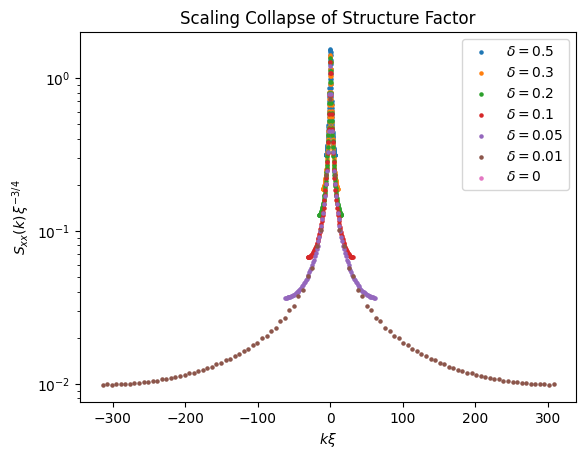

In [2]:
import sys
sys.path.append("../../src")
from common_imports import *
import kblock_ising_model as kb
from equilibrium_critical_correlations import sigma_general

In [53]:
###
#Plotting Stuff
###
folder = "Figures/"


/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


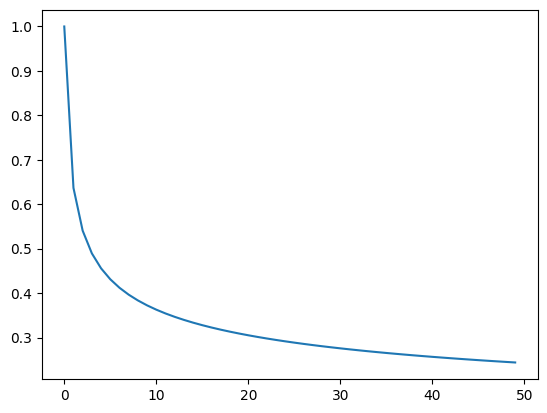

In [54]:
r = np.arange(0,50)
L = 1000
xx_eq = array([sigma_general([0,i]) for i in r])
plot(r,xx_eq)

In [55]:
def xx_g(g,r):
    k = kb.k_vals(L)
    U = kb.U(k,g)

    return array([kb.sigma_general([0,i],U,k) for i in r])

In [56]:
g_vals = array([1.5,1.3,1.2,1.1,1.05,1.01,1])

r = np.arange(1,50)

data_array =[]
for g in tqdm(g_vals):
    data_array.append(xx_g(g,r))
    

  0%|          | 0/7 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 7/7 [00:15<00:00,  2.25s/it]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35748/3161483951.py:6: RuntimeWarning: invalid value encountered in power
  plot(r_scaled,d*r**(1/4),label=r"$\delta=$"+str(delta)[:4])


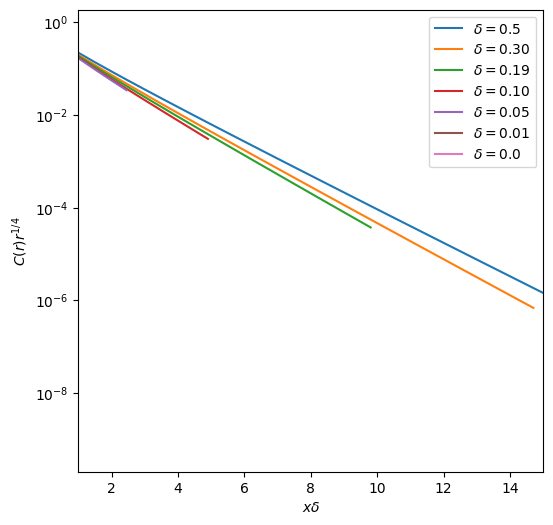

In [133]:
plt.figure(figsize=(6,6))
for i, d in enumerate(data_array):
    g = g_vals[i]
    delta = abs(g-1)
    r_scaled = r*delta
    plot(r_scaled,d*r**(1/4),label=r"$\delta=$"+str(delta)[:4])

path = folder+filename
#title(r"$f(x\delta)$ collapse")
xlabel(r"$x\delta$")
#xlabel(r"$r$")

ylabel(r"$C(r) r^{1/4}$")
xlim(1,15)
#ylim(0.01,0.4)
filename= "groundstate_corr_scaling_collapse_log.png"
yscale("log")
legend(loc="upper right")
path=  folder+filename
plt.savefig(path,dpi=800)



# Structure Factor

In [68]:
from numpy.fft import fftfreq, fftshift, fft

In [69]:
g_vals = array([1.5,1.3,1.2,1.1,1.05,1.01,1])

r = np.arange(-50,50)

data_array =[]
for g in tqdm(g_vals):
    data_array.append(xx_g(g,r))

  0%|          | 0/7 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/October /../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 7/7 [00:32<00:00,  4.64s/it]


/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35748/247970241.py:6: RuntimeWarning: invalid value encountered in power
  plot(k*delta,abs(f)/k**(3/4),label=delta)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35748/247970241.py:6: RuntimeWarning: divide by zero encountered in divide
  plot(k*delta,abs(f)/k**(3/4),label=delta)


(0.06283185307179595, 3.141592653589793)

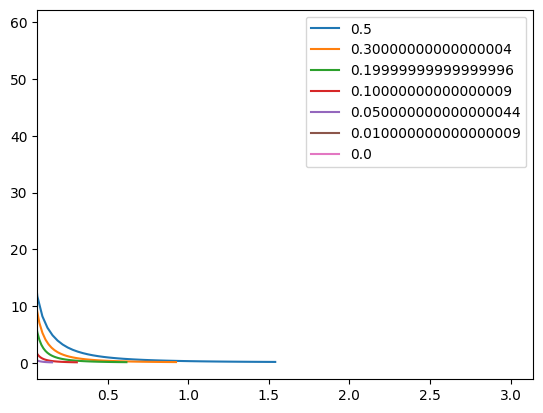

In [90]:
k = fftshift(fftfreq(len(r),1))*2*pi
dk = k[1]-k[0]
for i,d in enumerate(data_array):
    f = fftshift(fft(d))
    delta = abs(g_vals[i]-1)
    plot(k*delta,abs(f)/k**(3/4),label=delta)
legend()
xlim(dk,pi)
#loglog()

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35748/3621603058.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  xi = 1 / delta           # since ν = 1
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_35748/3621603058.py:7: RuntimeWarning: invalid value encountered in multiply
  scaled_k = k * xi


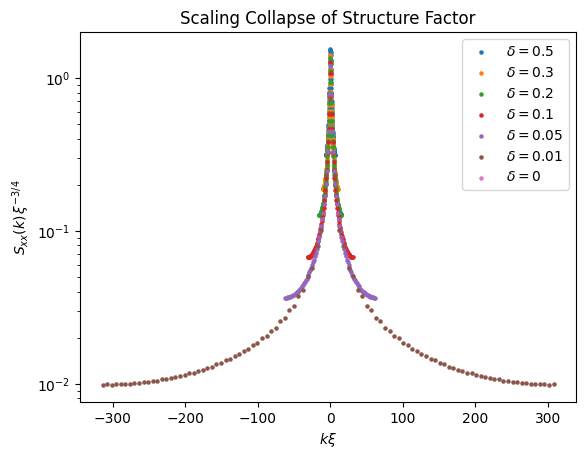

In [141]:
k = fftshift(fftfreq(len(r), 1)) * 2 * np.pi
dk = k[1]-k[0]
for i, d in enumerate(data_array):
    f = fftshift(fft(d))
    delta = abs(g_vals[i] - 1)
    xi = 1 / delta           # since ν = 1
    scaled_k = k * xi
    scaled_S = abs(f) * xi**(-3/4)
    #plt.plot(k, abs(f), label=rf"$\delta = ${delta:.3g}")

    plt.scatter(scaled_k, scaled_S, label=rf"$\delta = ${delta:.3g}",s=5)

#plt.xscale("log")
plt.yscale("log")
#plt.xlim(dk, np.pi)
plt.legend()
plt.xlabel(r"$k\xi$")
plt.ylabel(r"$S_{xx}(k)\,\xi^{-3/4}$")
title("Scaling Collapse of Structure Factor")
filename= "scaling_collapse_structure_factor_loglog.png"
#plt.savefig(folder+filename,dpi=800)